# California Housing Prices

## Importing data

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [2]:
df = pd.read_csv("data/housing.csv")
df.shape

(20640, 10)

In [3]:
df.head()

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity
0,-122.23,37.88,41.0,880.0,129.0,322.0,126.0,8.3252,452600.0,NEAR BAY
1,-122.22,37.86,21.0,7099.0,1106.0,2401.0,1138.0,8.3014,358500.0,NEAR BAY
2,-122.24,37.85,52.0,1467.0,190.0,496.0,177.0,7.2574,352100.0,NEAR BAY
3,-122.25,37.85,52.0,1274.0,235.0,558.0,219.0,5.6431,341300.0,NEAR BAY
4,-122.25,37.85,52.0,1627.0,280.0,565.0,259.0,3.8462,342200.0,NEAR BAY


In [4]:
df.describe()

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value
count,20640.000000,20640.000000,20640.000000,20640.000000,20433.000000,20640.000000,20640.000000,20640.000000,20640.000000
mean,-119.569704,35.631861,28.639486,2635.763081,537.870553,1425.476744,499.539680,3.870671,206855.816909
std,2.003532,2.135952,12.585558,2181.615252,421.385070,1132.462122,382.329753,1.899822,115395.615874
min,-124.350000,32.540000,1.000000,2.000000,1.000000,3.000000,1.000000,0.499900,14999.000000
25%,-121.800000,33.930000,18.000000,1447.750000,296.000000,787.000000,280.000000,2.563400,119600.000000
50%,-118.490000,34.260000,29.000000,2127.000000,435.000000,1166.000000,409.000000,3.534800,179700.000000
75%,-118.010000,37.710000,37.000000,3148.000000,647.000000,1725.000000,605.000000,4.743250,264725.000000
max,-114.310000,41.950000,52.000000,39320.000000,6445.000000,35682.000000,6082.000000,15.000100,500001.000000


## EDA and Feature Engineering

In [5]:
df.isnull().sum()

longitude               0
latitude                0
housing_median_age      0
total_rooms             0
total_bedrooms        207
population              0
households              0
median_income           0
median_house_value      0
ocean_proximity         0
dtype: int64

In [6]:
df["total_bedrooms"].skew()

np.float64(3.459546331523342)

In [7]:
df["total_bedrooms"] = df["total_bedrooms"].fillna(df["total_bedrooms"].median())
df.isnull().sum()

longitude             0
latitude              0
housing_median_age    0
total_rooms           0
total_bedrooms        0
population            0
households            0
median_income         0
median_house_value    0
ocean_proximity       0
dtype: int64

In [8]:
df["rooms_per_household"] = df["total_rooms"] / df["households"]
df["rooms_per_household"].head()

0    6.984127
1    6.238137
2    8.288136
3    5.817352
4    6.281853
Name: rooms_per_household, dtype: float64

In [9]:
df["bedrooms_per_household"] = df["total_bedrooms"] / df["households"]
df["bedrooms_per_household"].head()

0    1.023810
1    0.971880
2    1.073446
3    1.073059
4    1.081081
Name: bedrooms_per_household, dtype: float64

In [10]:
df["household_size"] = df["population"] / df["households"]
df["household_size"].head()

0    2.555556
1    2.109842
2    2.802260
3    2.547945
4    2.181467
Name: household_size, dtype: float64

In [11]:
df = pd.get_dummies(df, columns=["ocean_proximity"], drop_first=True, dtype=int)
df.head()

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,rooms_per_household,bedrooms_per_household,household_size,ocean_proximity_INLAND,ocean_proximity_ISLAND,ocean_proximity_NEAR BAY,ocean_proximity_NEAR OCEAN
0,-122.23,37.88,41.0,880.0,129.0,322.0,126.0,8.3252,452600.0,6.984127,1.023810,2.555556,0,0,1,0
1,-122.22,37.86,21.0,7099.0,1106.0,2401.0,1138.0,8.3014,358500.0,6.238137,0.971880,2.109842,0,0,1,0
2,-122.24,37.85,52.0,1467.0,190.0,496.0,177.0,7.2574,352100.0,8.288136,1.073446,2.802260,0,0,1,0
3,-122.25,37.85,52.0,1274.0,235.0,558.0,219.0,5.6431,341300.0,5.817352,1.073059,2.547945,0,0,1,0
4,-122.25,37.85,52.0,1627.0,280.0,565.0,259.0,3.8462,342200.0,6.281853,1.081081,2.181467,0,0,1,0


In [12]:
df.corr()["median_house_value"].sort_values(ascending=False)

median_house_value            1.000000
median_income                 0.688075
ocean_proximity_NEAR BAY      0.160284
rooms_per_household           0.151948
ocean_proximity_NEAR OCEAN    0.141862
total_rooms                   0.134153
housing_median_age            0.105623
households                    0.065843
total_bedrooms                0.049457
ocean_proximity_ISLAND        0.023416
household_size               -0.023737
population                   -0.024650
bedrooms_per_household       -0.045637
longitude                    -0.045967
latitude                     -0.144160
ocean_proximity_INLAND       -0.484859
Name: median_house_value, dtype: float64

<Axes: >

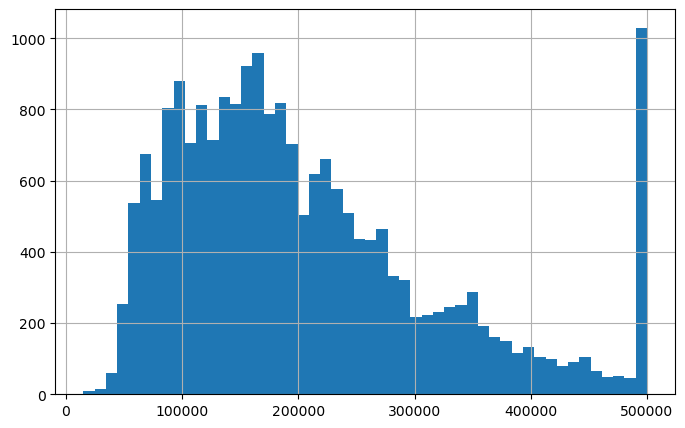

In [13]:
df["median_house_value"].hist(bins=50, figsize=(8,5))

In [14]:
df["median_house_value"].max()

500001.0

**Note:** Median_house_value is capped at 500001. The spike at the right of the histogram is not real data (it represents all houses that were worth more than $500k). This means model will underpredict expensive houses since it has no information about what drives values above that threshold.

In [15]:
df.drop(columns=["total_rooms", "total_bedrooms", "population", "households", "longitude", "latitude"], inplace=True)

In [16]:
df.head()

,housing_median_age,median_income,median_house_value,rooms_per_household,bedrooms_per_household,household_size,ocean_proximity_INLAND,ocean_proximity_ISLAND,ocean_proximity_NEAR BAY,ocean_proximity_NEAR OCEAN
0,41.0,8.3252,452600.0,6.984127,1.023810,2.555556,0,0,1,0
1,21.0,8.3014,358500.0,6.238137,0.971880,2.109842,0,0,1,0
2,52.0,7.2574,352100.0,8.288136,1.073446,2.802260,0,0,1,0
3,52.0,5.6431,341300.0,5.817352,1.073059,2.547945,0,0,1,0
4,52.0,3.8462,342200.0,6.281853,1.081081,2.181467,0,0,1,0


## Train/Test

In [17]:
from sklearn.model_selection import train_test_split

X = df.drop(columns=["median_house_value"])
y = df["median_house_value"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print(X_train.shape, X_test.shape)
print(f"{y_train.mean():.3f}, {y_train.mean():.3f}")

(16512, 9) (4128, 9)
207194.694, 207194.694


## Model Selection

In [18]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [19]:
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.model_selection import cross_val_score

models = {
    "Linear Regression": LinearRegression(),
    "Decision Tree": DecisionTreeRegressor(random_state=42),
    "Gradient Boosting": GradientBoostingRegressor(random_state=42)
}

for name, model in models.items():
    scores = cross_val_score(model, X_train_scaled, y_train, cv=5, scoring="neg_root_mean_squared_error")
    print(f"{name}: mean={-scores.mean():.3f}, std={scores.std():.3f}")

Linear Regression: mean=72358.912, std=729.884
Decision Tree: mean=83294.641, std=1089.440
Gradient Boosting: mean=60175.075, std=856.287


In [20]:
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

for name, model in models.items():
    model.fit(X_train_scaled, y_train)
    y_pred = model.predict(X_test_scaled)

    print(f"\n-----{name}-----")
    print(f"MSE: {mean_squared_error(y_test, y_pred):.3f}")
    print(f"MAE: {mean_absolute_error(y_test, y_pred):.3f}")
    print(f"R2: {r2_score(y_test, y_pred):.3f}")


-----Linear Regression-----
MSE: 6646324572.518
MAE: 54471.348
R2: 0.493

-----Decision Tree-----
MSE: 6829443390.889
MAE: 56811.625
R2: 0.479

-----Gradient Boosting-----
MSE: 3822931554.224
MAE: 43464.823
R2: 0.708


In [21]:
for name, model in models.items():
    train_score = model.score(X_train_scaled, y_train)
    test_score = model.score(X_test_scaled, y_test)
    print(f"{name}: train={train_score:.3f}, test={test_score:.3f}")

Linear Regression: train=0.610, test=0.493
Decision Tree: train=1.000, test=0.479
Gradient Boosting: train=0.752, test=0.708


In [22]:
from sklearn.model_selection import GridSearchCV

param_grid = {
    "n_estimators": [100, 200],
    "learning_rate": [0.05, 0.1, 0.2],
    "max_depth": [3, 4, 5],
    "subsample": [0.8, 1.0]
}

grid_search = GridSearchCV(
    GradientBoostingRegressor(random_state=42),
    param_grid, 
    cv=5, 
    scoring="r2",
    n_jobs=-1
)

grid_search.fit(X_train_scaled, y_train)
print(f"Best params: {grid_search.best_params_}")
print(f"Best CV R2: {grid_search.best_score_}")

Best params: {'learning_rate': 0.05, 'max_depth': 5, 'n_estimators': 200, 'subsample': 0.8}
Best CV R2: 0.7422687534400495


In [23]:
# Orginal
original = GradientBoostingRegressor(random_state=42)
original.fit(X_train_scaled, y_train)

# Tuned
tuned = GradientBoostingRegressor(
    random_state=42,
    learning_rate=0.05,
    max_depth=5,
    n_estimators=200,
    subsample=0.8
)
tuned.fit(X_train_scaled, y_train)

for name, model in [("Original", original), ("Tuned", tuned)]:
    y_pred = model.predict(X_test_scaled)
    train_score = model.score(X_train_scaled, y_train)
    test_score = model.score(X_test_scaled, y_test)

    print(f"\n-----{name}-----")
    print(f"Train: {train_score:.3f} | Test: {test_score:.3f} | Gap: {train_score-test_score:.3f}")
    print(f"MSE: {mean_squared_error(y_test, y_pred):.3f}")
    print(f"MAE: {mean_absolute_error(y_test, y_pred):.3f}")
    print(f"R2: {r2_score(y_test, y_pred):.3f}")


-----Original-----
Train: 0.752 | Test: 0.708 | Gap: 0.044
MSE: 3822931554.224
MAE: 43464.823
R2: 0.708

-----Tuned-----
Train: 0.801 | Test: 0.725 | Gap: 0.076
MSE: 3604904599.672
MAE: 41686.446
R2: 0.725


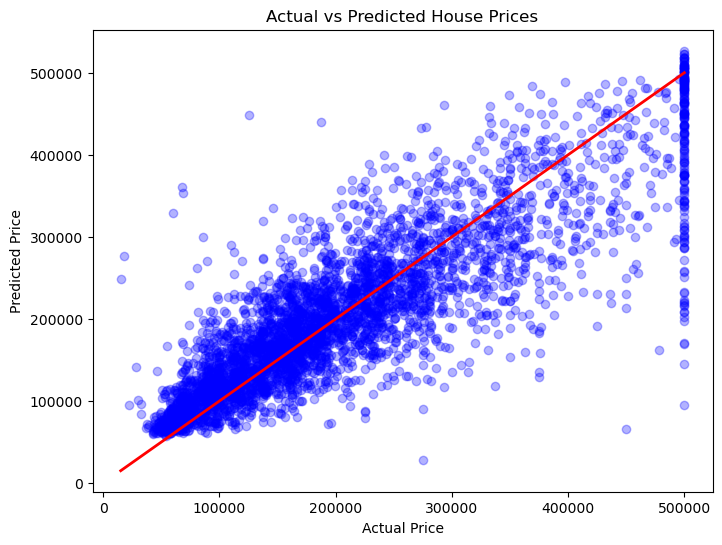

In [26]:
y_pred_tuned = tuned.predict(X_test_scaled)

plt.figure(figsize=(8, 6))
plt.scatter(y_test, y_pred_tuned, alpha=0.3, color='blue')
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 
         color='red', linewidth=2)
plt.xlabel('Actual Price')
plt.ylabel('Predicted Price')
plt.title('Actual vs Predicted House Prices')
plt.show()

## Conclusion

Gradient Boosting with tuned hyperparameters achieved R²=0.725 and MAE=$41,686.

The model performs well in the 100k-350k range where most data is concentrated.
Performance degrades at higher prices due to the $500,001 cap in the dataset (
houses above that threshold are all recorded as the same value, making it impossible
for the model to learn what drives luxury pricing).

To improve this model further:
- Remove or treat the capped values separately
- Add geographic clustering features from latitude/longitude
- Try XGBoost or LightGBM for potentially better performance